<a href="https://colab.research.google.com/github/nashwanadilah/flood-risk-modeling/blob/main/IHSG_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PENDAHULUAN

**IHSG & Sectoral Stock Performance**

Lima saham representatif dipilih dari sektor yang berbeda untuk membandingkan bagaimana karaketeristik industri memengaruhi performa dan risiko investasi secara berbeda

Saham yang di analisis dalam proyek ini :
- Sektor Keuangan : BBCA (BCA)
- Sektor Konsumer : UNVR (Unilever)
- Sektor Pertambangan : ADRO (adaro)
- Infrastruktur : TLKM (Telkom)
- Sektor Properti : BSDE (BSD city)

dan IHSG sebagai benchmark

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#DATA COLLECTION

Pada bagian ini, data closing price harian diunduh dari Yahoo Finance menggunakan library 'yfinance'

Periode 2020–2025 dipilih karena mencakup siklus lengkap pasar saham, mulai dari krisis (COVID-19), pemulihan, boom komoditas, normalisasi, hingga stabilisasi menjelang pemilu dan kebijakan fiskal baru. Dengan rentang ini, kita bisa melihat bagaimana masing-masing sektor bereaksi terhadap berbagai jenis sentimen, baik yang bersifat global maupun domestik.

In [3]:
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif", "axes.titlesize": 14, "axes.titleweight": "bold", "axes.labelsize": 11, "legend.fontsize": 10, "figure.dpi": 120})
COLORS = {
    "IHSG":          "#1B4F72",
    "Financial":     "#2E86C1",
    "Consumer":      "#28B463",
    "Mining":        "#E67E22",
    "Infrastructure":"#8E44AD",
    "Property":      "#C0392B",}

# Ticker IDX sektoral di Yahoo Finance
TICKERS = {
    "IHSG":        "^JKSE",
    "Financial":   "BBCA.JK",
    "Consumer":    "UNVR.JK",
    "Mining":      "ADRO.JK",
    "Telco":       "TLKM.JK",
    "Property":    "BSDE.JK",
}
START_DATE = "2020-01-01"
END_DATE   = "2025-12-31"

price_list = {}

for name, ticker in TICKERS.items():
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)
    close = df["Close"]
    if isinstance(close.columns, pd.MultiIndex):
        close = close.droplevel(1, axis=1)
    close.columns = [name]
    price_list[name] = close.squeeze()  # pastikan jadi Series
    print(f"[✓] {name} — {len(df)} baris")

prices = pd.DataFrame(price_list)
prices = prices.ffill().dropna(how="all")

print("\nDataFrame final:")
print(prices.shape)
print(prices.head())

[✓] IHSG — 1447 baris
[✓] Financial — 1447 baris
[✓] Consumer — 1447 baris
[✓] Mining — 1447 baris
[✓] Telco — 1447 baris
[✓] Property — 1447 baris

DataFrame final:
(1447, 6)
                   IHSG    Financial     Consumer      Mining        Telco  \
Date                                                                         
2020-01-02  6283.581055  5782.699707  6763.019531  429.990448  2864.556396   
2020-01-03  6323.465820  5877.782227  6782.794434  440.662598  2915.840088   
2020-01-06  6257.402832  5821.597168  6703.694336  440.662598  2901.187500   
2020-01-07  6279.346191  5825.917969  6683.919434  463.222107  2886.535156   
2020-01-08  6225.686035  5774.056152  6585.043457  452.694366  2857.230225   

            Property  
Date                  
2020-01-02    1270.0  
2020-01-03    1290.0  
2020-01-06    1280.0  
2020-01-07    1250.0  
2020-01-08    1220.0  


#Trend & Return Analysis

In [12]:
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 120})
COLORS = {
    "IHSG":       "#1B4F72",
    "Financial":  "#2E86C1",
    "Consumer":   "#28B463",
    "Mining":     "#E67E22",
    "Telco":      "#8E44AD",
    "Property":   "#C0392B",}

Normalized Chart

Seluruh harga saham di normalisasi ke nilai **100** pada tanggal 1 Januari 2020. Artinya, semua saham dimulai dari titik yang sama sehingga perbandingan performa antar saham menjadi adil terlepas dari perbedaan harga absolutnya

Terlihat dari grafik bahwa sektor mining dan consumer menjadi pemimpin untuk pertumbuhan jangka panjang sementara Telco paling lambat. Secara keseluruhan, pasar modal Indonesia mengalami **bullish trend** yang konsisten dari 2020 hingga 2025

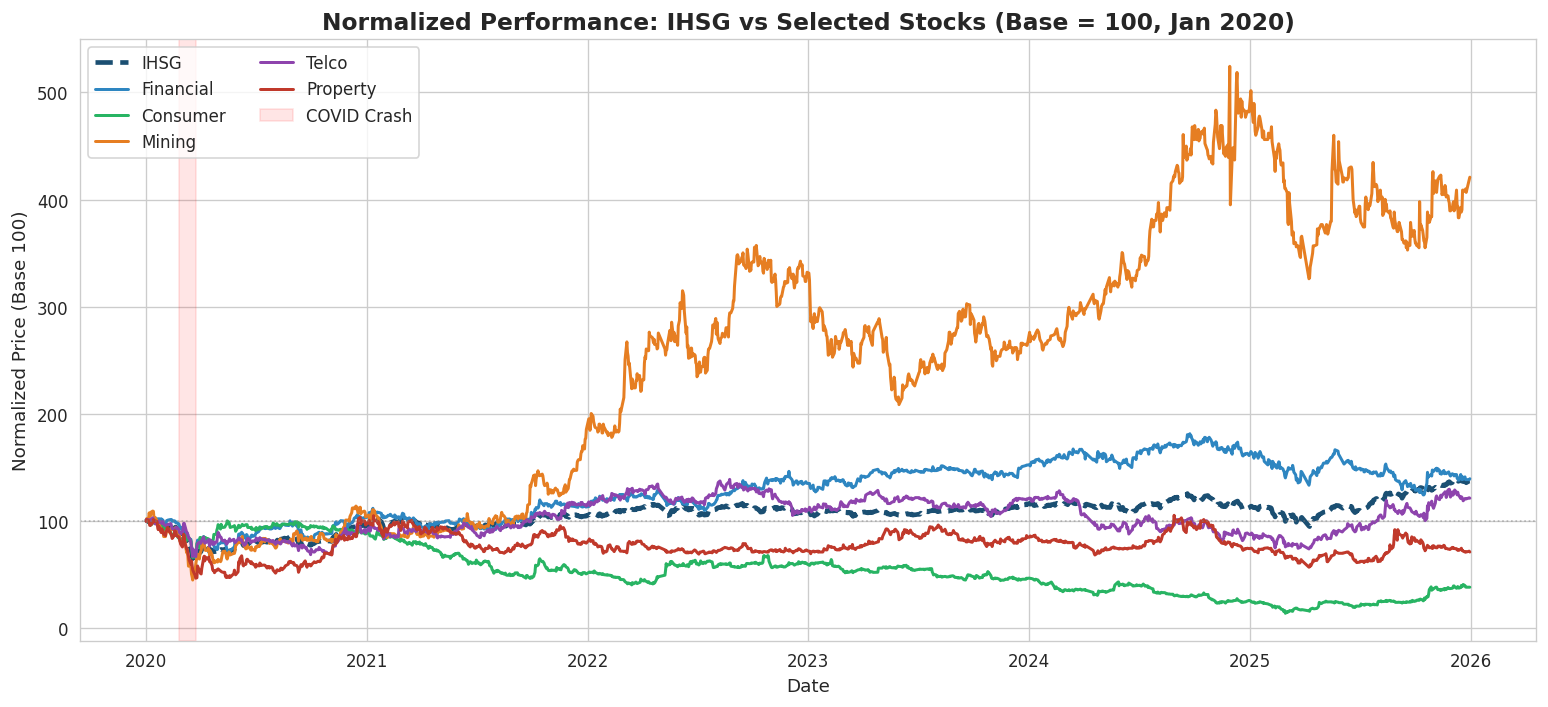

In [13]:
normalized = prices.div(prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(13, 6))

for col in normalized.columns:
    lw = 2.8 if col == "IHSG" else 1.8
    ls = "--" if col == "IHSG" else "-"
    ax.plot(normalized.index, normalized[col],
            label=col,
            color=COLORS.get(col, "#999999"),
            linewidth=lw,
            linestyle=ls)

ax.axvspan(pd.Timestamp("2020-02-25"), pd.Timestamp("2020-03-24"),
           alpha=0.10, color="red", label="COVID Crash")
ax.axhline(100, color="gray", linestyle=":", linewidth=1, alpha=0.5)
ax.set_title("Normalized Performance: IHSG vs Selected Stocks (Base = 100, Jan 2020)")
ax.set_ylabel("Normalized Price (Base 100)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

**Yearly Return Chart**

Menghitung total return masing-masing saham dari 2020 hingga 2025
Return dihitung dengan rumus sederhana

Return (%) = ((Harga Akhir Tahun / Harga Awal Tahun) - 1) × 100

Analisis ini menunjukkan bahwa sektor paling dominan adalah mining dan financial yang stabil positif setiap tahunnya. Sektor yang paling volatil ialah konsumer dan sektor yang paling tertinggal adalah sektor telco yang mencatat kinerja negatif setiap tahun dan sektor property baru menunjukkan perbaikan di 2023 tetapi masih negatif di 2024-2025

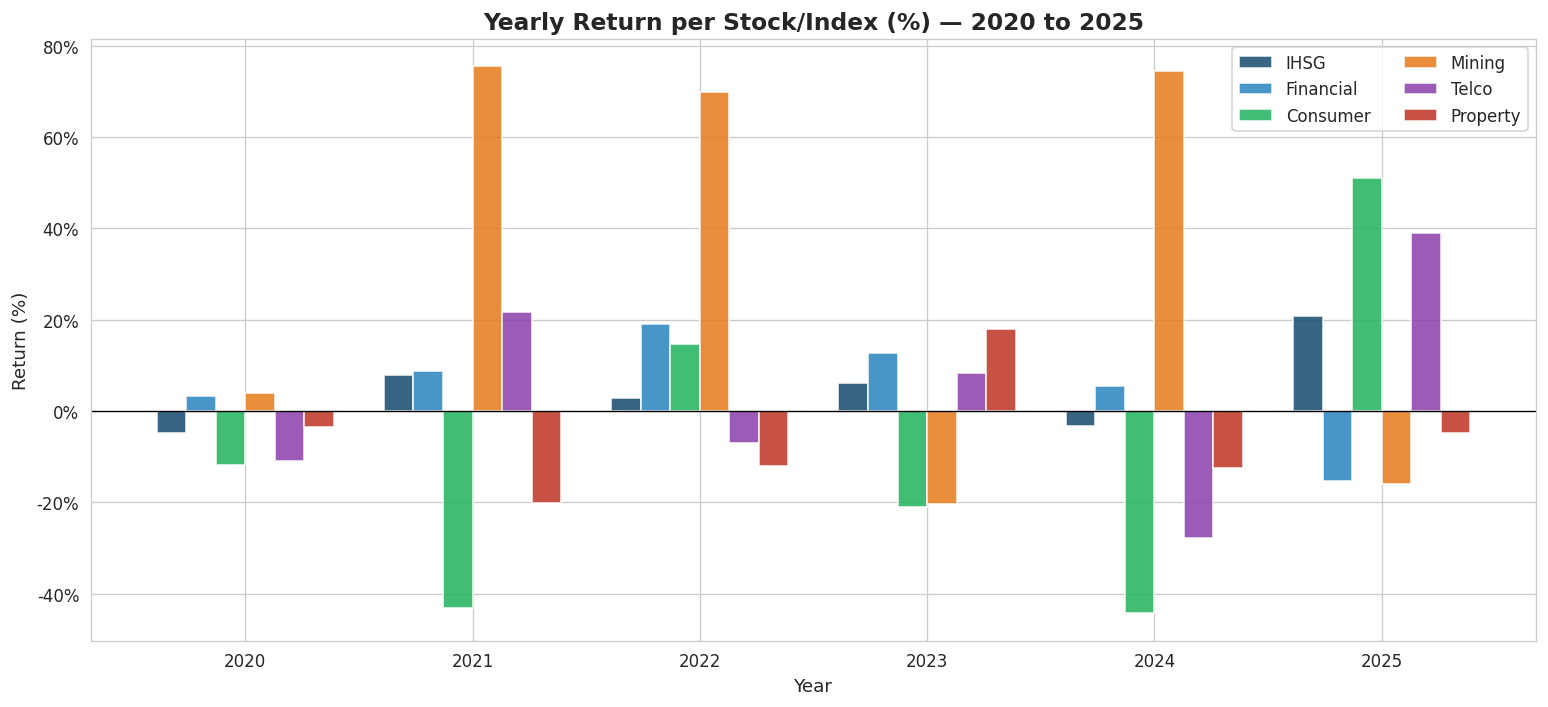

In [14]:
yearly_returns = {}
for year in range(2020, 2026):
    year_data = prices[prices.index.year == year]
    if len(year_data) < 2:
        continue
    ret = (year_data.iloc[-1] / year_data.iloc[0] - 1) * 100
    yearly_returns[year] = ret

returns_df = pd.DataFrame(yearly_returns).T

fig, ax = plt.subplots(figsize=(13, 6))

n_cols = len(returns_df.columns)
bar_width = 0.13
x = range(len(returns_df))
offsets = [(i - n_cols / 2 + 0.5) * bar_width for i in range(n_cols)]

for i, col in enumerate(returns_df.columns):
    ax.bar(
        [xi + offsets[i] for xi in x],
        returns_df[col],
        width=bar_width,
        label=col,
        color=COLORS.get(col, "#999999"),
        alpha=0.88
    )

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(returns_df.index.astype(str))
ax.set_title("Yearly Return per Stock/Index (%) — 2020 to 2025")
ax.set_ylabel("Return (%)")
ax.set_xlabel("Year")
ax.legend(loc="upper right", ncol=2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
plt.tight_layout()
plt.show()

**Cumulative Return Ranking**

Menghitung total return masing-masing saham selama seluruh periode 2020-2025 dan menampilkannya dalam bentuk ranking.

Analisis ini menunjukkan bahwa sektor mining mencatatkan return tertinggi

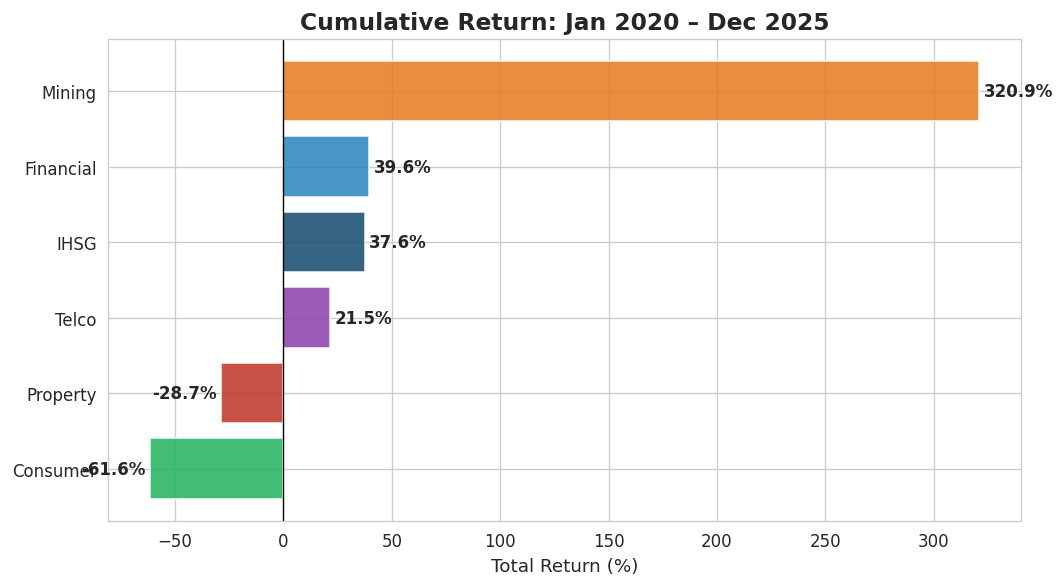

In [15]:
cumulative = (prices.iloc[-1] / prices.iloc[0] - 1) * 100
cumulative_df = cumulative.sort_values(ascending=False).reset_index()
cumulative_df.columns = ["Stock", "Total Return (%)"]
cumulative_df["Total Return (%)"] = cumulative_df["Total Return (%)"].round(2)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [COLORS.get(s, "#95A5A6") for s in cumulative_df["Stock"]]
bars = ax.barh(cumulative_df["Stock"], cumulative_df["Total Return (%)"],
               color=bar_colors, alpha=0.88)

for bar, val in zip(bars, cumulative_df["Total Return (%)"]):
    offset = 2 if val >= 0 else -2
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", ha=ha,
            fontsize=10, fontweight="bold")

ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Cumulative Return: Jan 2020 – Dec 2025")
ax.set_xlabel("Total Return (%)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Moving Average**

Moving Average (MA) adalah rata-rata closing price dalam periode tertentu yang dihitung secara bergulir setiap hari.

Dalam analisis ini digunakan dua jenis MA
- MA30 : rata-rata 30 hari terakhir (jangka pendek)
- MA100 : rata-rata 100 hari terakhir (jangka menengah)

MA30 dan MA100 cukup efektif dalam indikator tren, meskipun tidak dapat memprediksi secara sempurna. Selama periode pemulihan 2021–2022, IHSG konsisten berada di atas kedua MA-nya, menandakan tren bullish yang kuat dan MA berfungsi sebagai level support dinamis. Namun, saat krisis COVID-19 di Maret 2020, MA30 dan MA100 sempat tertinggal dalam merespons penurunan tajam IHSG karena sifatnya yang lagging (berdasarkan data masa lalu). Dengan kata lain, MA lebih cocok digunakan untuk mengonfirmasi arah tren dan menentukan level support/resistance, bukan untuk memprediksi titik balik secara akurat, terutama dalam kondisi pasar yang sangat volatil.

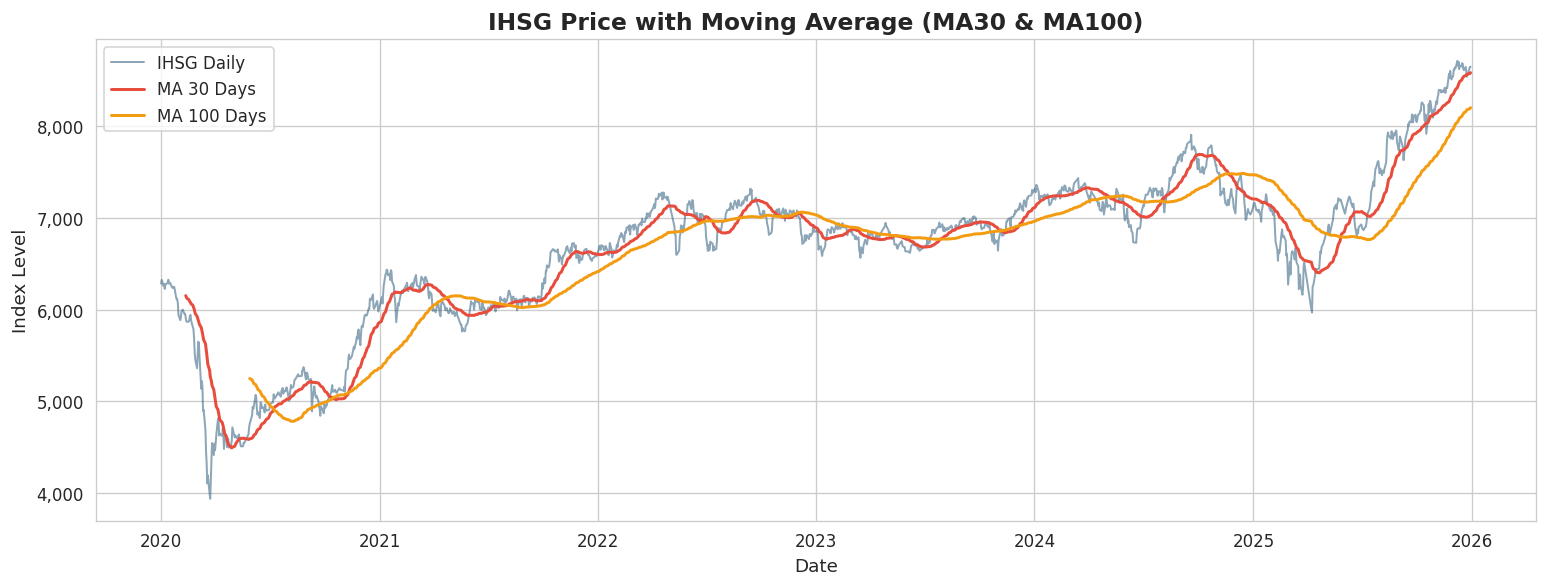

In [16]:
ihsg = prices["IHSG"].copy()
ma30  = ihsg.rolling(window=30).mean()
ma100 = ihsg.rolling(window=100).mean()

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(ihsg.index, ihsg,
        color="#1B4F72", linewidth=1.2, alpha=0.5, label="IHSG Daily")
ax.plot(ma30.index, ma30,
        color="#E74C3C", linewidth=1.8, label="MA 30 Days")
ax.plot(ma100.index, ma100,
        color="#F39C12", linewidth=1.8, label="MA 100 Days")

ax.set_title("IHSG Price with Moving Average (MA30 & MA100)")
ax.set_ylabel("Index Level")
ax.set_xlabel("Date")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

#Volatillity Analysis


Volatilitas adalah ukuran seberapa besar dan seberapa cepat
harga suatu saham bergerak naik atau turun dalam periode tertentu.

Semakin tinggi volatilitas, semakin besar pergerakan harganya artinya potensi keuntungan lebih besar tapi potensi kerugian juga lebih besar

Annualized Volatility

In [17]:
daily_returns = prices.pct_change().dropna()

annualized_vol = daily_returns.std()*(252**0.5)*100
annualized_vol = annualized_vol.sort_values(ascending=False)

print('Annualized Vollatility:')
print(annualized_vol.round(2).to_string())

Annualized Vollatility:
Mining       46.59
Property     39.74
Consumer     39.61
Telco        31.58
Financial    26.31
IHSG         16.94


Terlihat bahwa mining menawarkan return tinggi tetapi dengan risiko fluktuasi terbesar

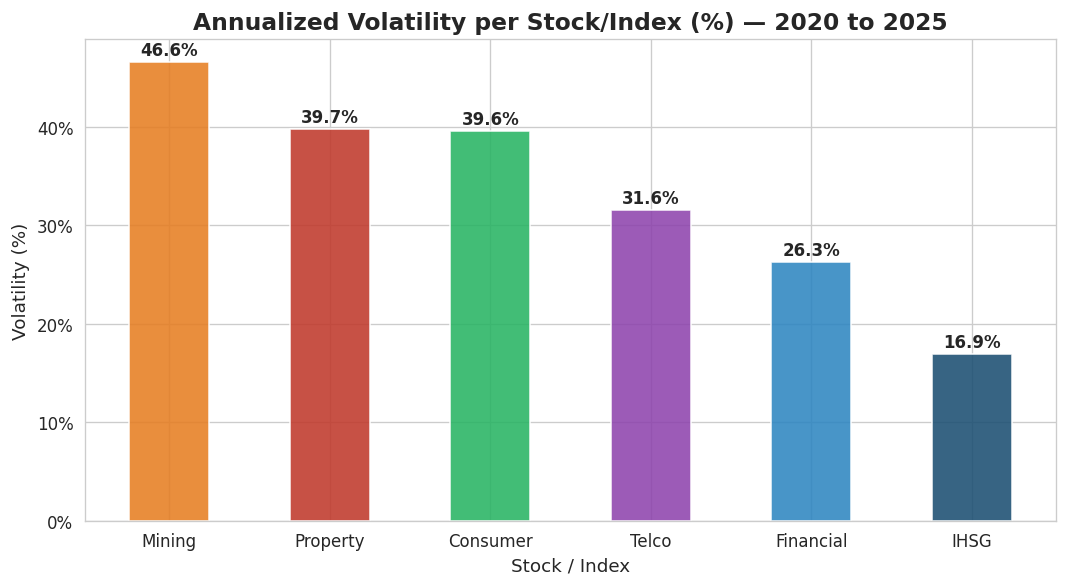

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

bar_colors = [COLORS.get(s, "#95A5A6") for s in annualized_vol.index]
bars = ax.bar(annualized_vol.index, annualized_vol.values,
              color=bar_colors, alpha=0.88, width=0.5)

for bar, val in zip(bars, annualized_vol.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.set_title("Annualized Volatility per Stock/Index (%) — 2020 to 2025")
ax.set_ylabel("Volatility (%)")
ax.set_xlabel("Stock / Index")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
plt.tight_layout()
plt.show()

Rolling 30-Day Volatility

Rolling 30-Day Volatility menghitung volatilitas secara bergulir setiap 30 hari. Artinya, setiap titik di grafik menunjukkan volatilitas saham dalam 30 hari sebelumnya.

Terlihat bahwa pandemi menyebabkan kejatuhan tajam untuk seluruh sektor.

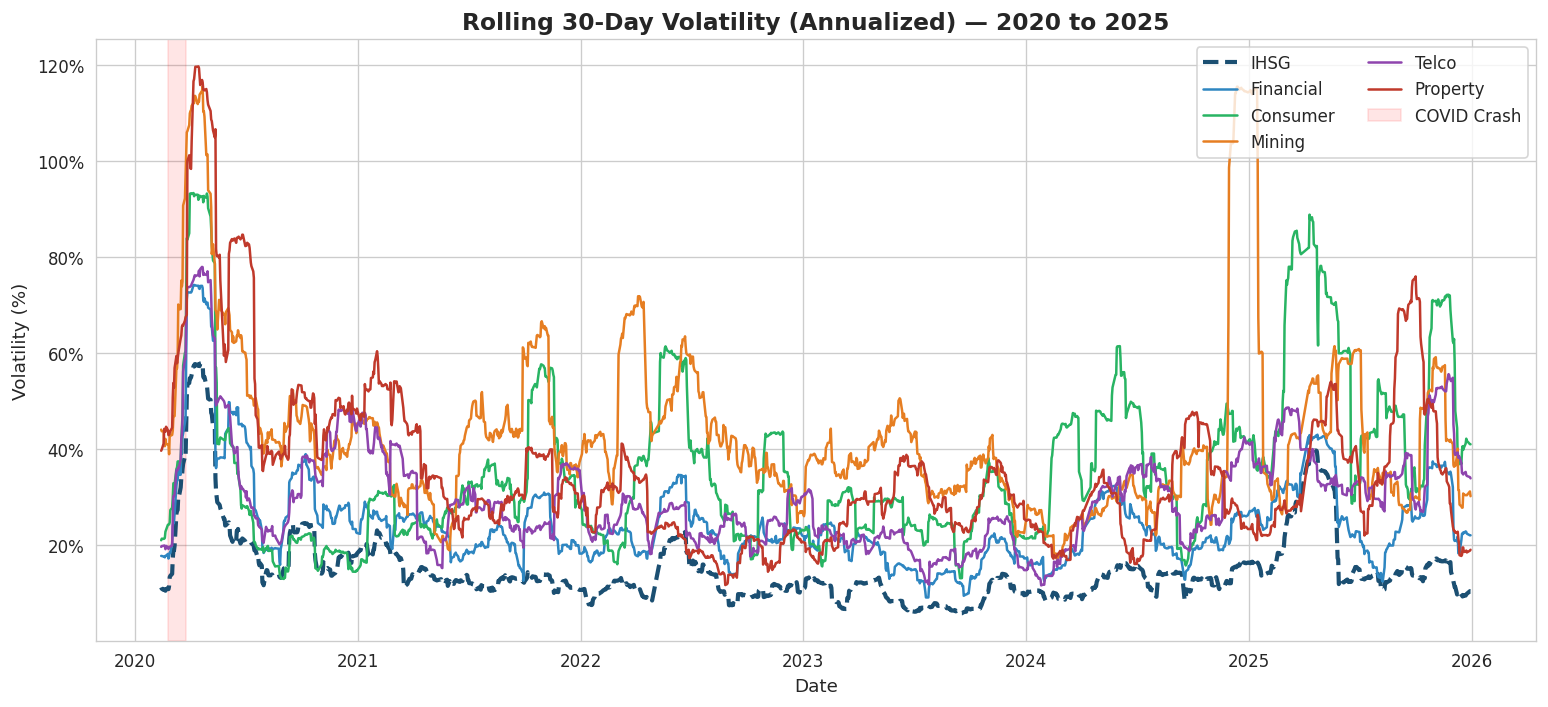

In [19]:
rolling_vol = daily_returns.rolling(window=30).std() * (252 ** 0.5) * 100

fig, ax = plt.subplots(figsize=(13, 6))

for col in rolling_vol.columns:
    lw = 2.5 if col == "IHSG" else 1.5
    ls = "--" if col == "IHSG" else "-"
    ax.plot(rolling_vol.index, rolling_vol[col],
            label=col,
            color=COLORS.get(col, "#999999"),
            linewidth=lw,
            linestyle=ls)

# Highlight COVID crash
ax.axvspan(pd.Timestamp("2020-02-24"), pd.Timestamp("2020-03-24"),
           alpha=0.10, color="red", label="COVID Crash")

ax.set_title("Rolling 30-Day Volatility (Annualized) — 2020 to 2025")
ax.set_ylabel("Volatility (%)")
ax.set_xlabel("Date")
ax.legend(loc="upper right", ncol=2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
plt.tight_layout()
plt.show()

Risk-Return Scatter Plot

- Kuadran kiri atas (Low risk, high return) memberikan return tinggi dengan risiko yang rendah
- Kuadran kanan atas (High risk, high return) return tinggi tapi dengan volatilitas yang besar
- Kuadran kanan bawah (High risk, low return) risikonya tinggi tapi return yang rendah bahkan negatif
- Kuadran kiri bawah (low risk, low return) return rendah tapi stabil

Terlihat bahwa sektor mining berada pada kuadran kanan atas yang menandakan bahwa sektor tersebut high risk high return, sedangkan untuk sektor seperti Financial dan telco berada pada kuadran kiri atas yang menandakan low risk high return.


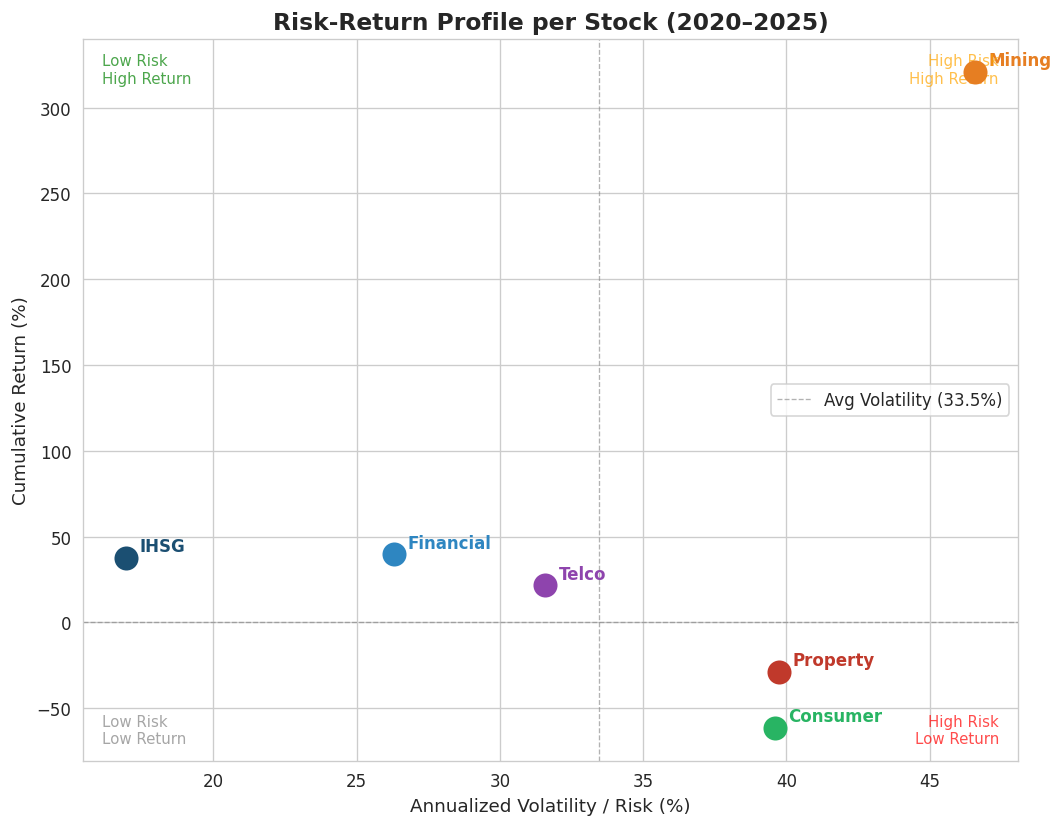

In [20]:
# Hitung total return per saham
total_return = (prices.iloc[-1] / prices.iloc[0] - 1) * 100

fig, ax = plt.subplots(figsize=(9, 7))

for stock in annualized_vol.index:
    x_val = annualized_vol[stock]
    y_val = total_return[stock]
    color = COLORS.get(stock, "#95A5A6")

    ax.scatter(x_val, y_val, color=color, s=180, zorder=5)
    ax.annotate(stock,
                xy=(x_val, y_val),
                xytext=(8, 4),
                textcoords="offset points",
                fontsize=10,
                fontweight="bold",
                color=color)

# Garis referensi
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axvline(annualized_vol.mean(), color="gray",
           linestyle="--", linewidth=0.8, alpha=0.6,
           label=f"Avg Volatility ({annualized_vol.mean():.1f}%)")

# Label kuadran
ax.text(0.02, 0.98, "Low Risk\nHigh Return",
        transform=ax.transAxes, fontsize=9,
        color="green", va="top", alpha=0.7)
ax.text(0.98, 0.98, "High Risk\nHigh Return",
        transform=ax.transAxes, fontsize=9,
        color="orange", va="top", ha="right", alpha=0.7)
ax.text(0.02, 0.02, "Low Risk\nLow Return",
        transform=ax.transAxes, fontsize=9,
        color="gray", va="bottom", alpha=0.7)
ax.text(0.98, 0.02, "High Risk\nLow Return",
        transform=ax.transAxes, fontsize=9,
        color="red", va="bottom", ha="right", alpha=0.7)

ax.set_title("Risk-Return Profile per Stock (2020–2025)")
ax.set_xlabel("Annualized Volatility / Risk (%)")
ax.set_ylabel("Cumulative Return (%)")
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
best_return  = total_return.idxmax()
worst_return = total_return.idxmin()
most_volatile   = annualized_vol.idxmax()
least_volatile  = annualized_vol.idxmin()

print("=" * 50)
print("  RINGKASAN VOLATILITY ANALYSIS")
print("=" * 50)
print(f"\nSaham return tertinggi  : {best_return} ({total_return[best_return]:.1f}%)")
print(f"Saham return terendah   : {worst_return} ({total_return[worst_return]:.1f}%)")
print(f"Saham paling volatil    : {most_volatile} ({annualized_vol[most_volatile]:.1f}%)")
print(f"Saham paling stabil     : {least_volatile} ({annualized_vol[least_volatile]:.1f}%)")
print(f"\nRata-rata volatilitas   : {annualized_vol.mean():.1f}%")

  RINGKASAN VOLATILITY ANALYSIS

Saham return tertinggi  : Mining (320.9%)
Saham return terendah   : Consumer (-61.6%)
Saham paling volatil    : Mining (46.6%)
Saham paling stabil     : IHSG (16.9%)

Rata-rata volatilitas   : 33.5%


#Correlation Analysis

Korelasi mengukur secarapa kuat hubungan pergerakan harga antara dua saham. Korelasi adalah fondasi penting dari konsep diversifikasi portofolio. Jika semua saham dalam portofolio berkorelasi tinggi, ketika pasar turun semua saham ikut turun bersamaan istilahnya tidak ada yang 'menahan' kerugian

In [24]:
corr_matrix = daily_returns.corr()

print("Correlation Matrix:")
print(corr_matrix.round(3).to_string())

Correlation Matrix:
            IHSG  Financial  Consumer  Mining  Telco  Property
IHSG       1.000      0.683     0.378   0.464  0.547     0.515
Financial  0.683      1.000     0.231   0.293  0.410     0.357
Consumer   0.378      0.231     1.000   0.148  0.199     0.150
Mining     0.464      0.293     0.148   1.000  0.239     0.209
Telco      0.547      0.410     0.199   0.239  1.000     0.205
Property   0.515      0.357     0.150   0.209  0.205     1.000


- Pergerakan IHSG sangat dipengaruhi oleh sektor financial dan telco
- Financial berkorelasi cukup merata dengan semua sektor, ini menunjukkan bahwa sektor financial (BBCA) berperan sebagai penghubung antar sektor dalam perekonomian
- Mining lebih dipengaruhi faktor eksternal (harga komoditas global) daripada dinamika domestik sehingga tidak selalu sejalan dengan sektor lain
- Property dan consumer tidak berkorelasi kuat (0.15) menunjukkan bahwa sektor property tidak selalu bergerak seirama dengan daya beli masyarakat (konsumen) karena property lebih dipengaruhi suku bunga dan kebijakan pemerintah.
- Pergerakan telco lebih dipengaruhi faktor internal industri (regulasi, persaingan) daripada kondisi ekonomi makro

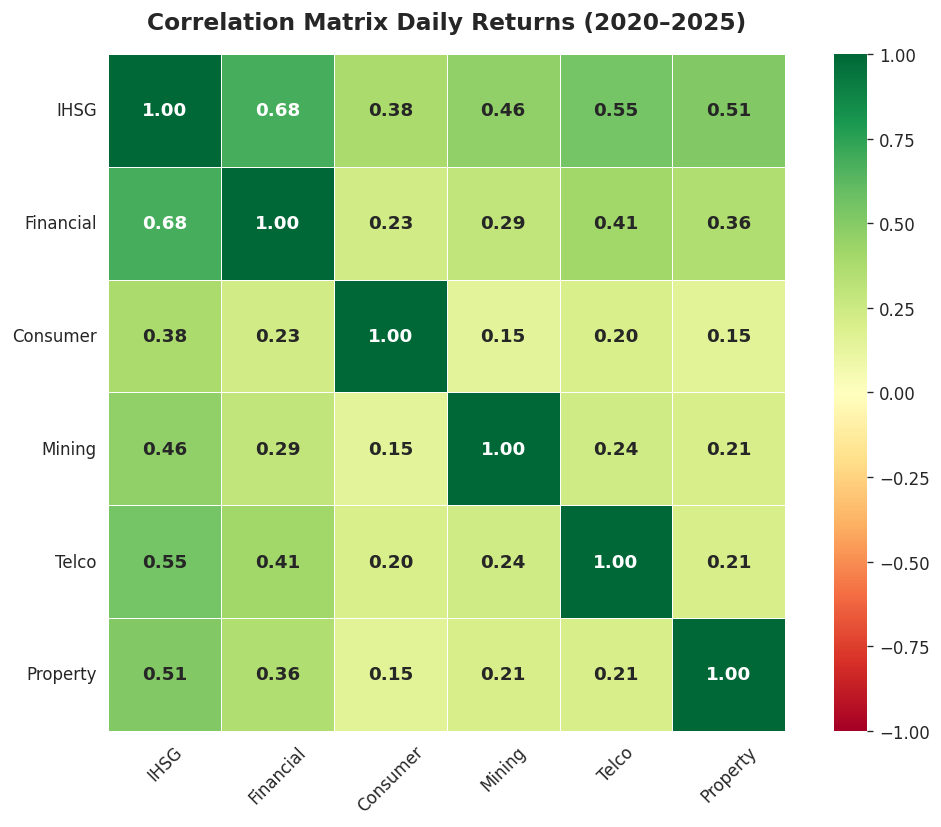

In [28]:
fig, ax = plt.subplots(figsize=(9, 7))

mask = pd.DataFrame(False, index=corr_matrix.index,
                    columns=corr_matrix.columns)

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, linecolor="white",
            annot_kws={"size": 11, "weight": "bold"}, ax=ax)

ax.set_title("Correlation Matrix Daily Returns (2020–2025)", pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

Pairwise Return Scatter (BBCA vs lainnya)

Visualisasi hubungan return BBCA dengan saham lain. BBCA dipilih karena paling stabil dibandingkan yang lain

- BBCA sangat erat dengan IHSG, karena BBCA adalah salah satu saham berkapitalisasi pasar terbesar di IHSG sehingga pergerakannya sangat mempengaruhi indeks
- Korelasi BBCA dengan sektor lain sedang
- Diversifikasi ke sektor dengan korelasi rendah ke BBCA (seperti consumer atau mining) bisa menjadi strategi mitigasi risiko

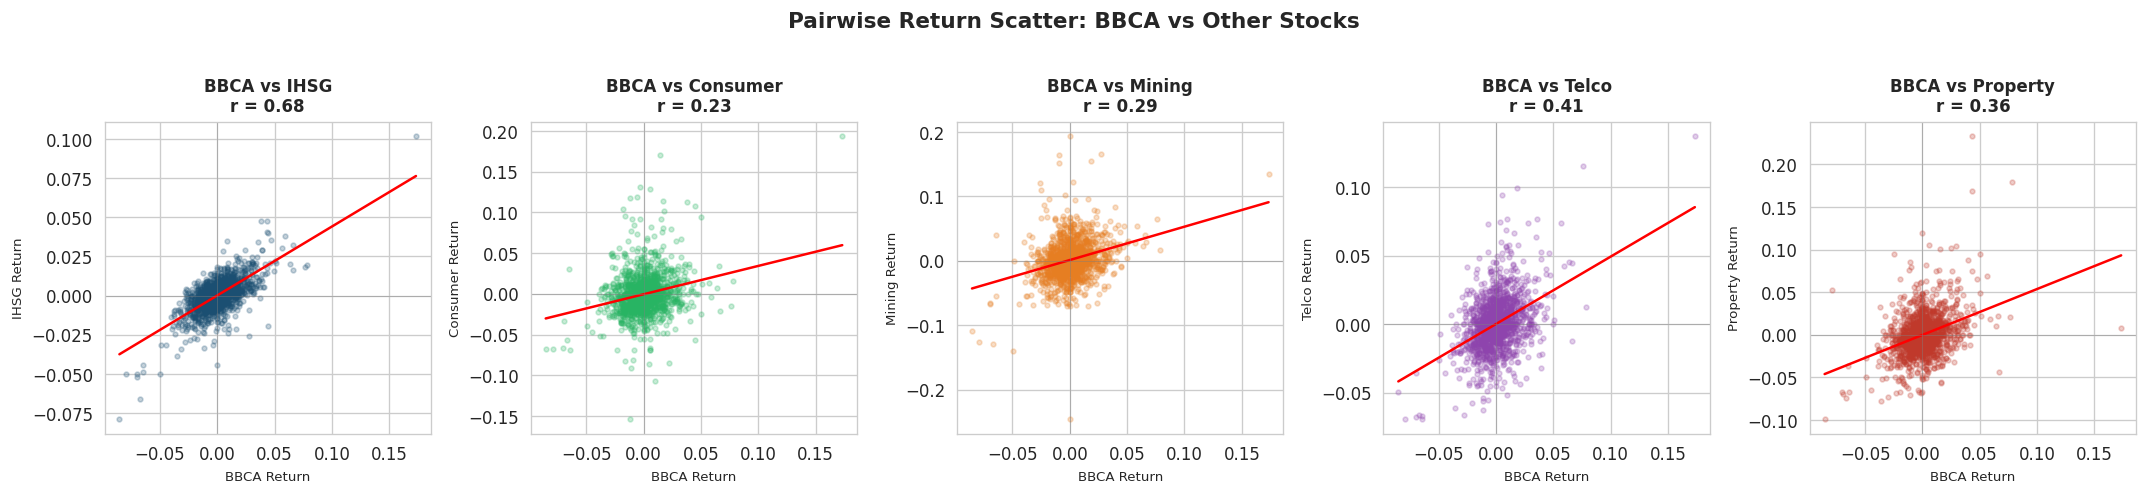

In [26]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

compare_to = "Financial"
others = [col for col in daily_returns.columns if col != compare_to]

for i, stock in enumerate(others):
    ax = axes[i]
    ax.scatter(daily_returns[compare_to], daily_returns[stock],
               alpha=0.25, s=8,
               color=COLORS.get(stock, "#999999"))

    # Tambah trend line
    z = pd.Series(daily_returns[stock]).dropna()
    x = pd.Series(daily_returns[compare_to]).dropna()
    common_idx = x.index.intersection(z.index)

    import numpy as np
    coeffs = np.polyfit(x[common_idx], z[common_idx], 1)
    trend = np.poly1d(coeffs)
    x_line = [x[common_idx].min(), x[common_idx].max()]
    ax.plot(x_line, trend(x_line), color="red", linewidth=1.5)

    corr_val = daily_returns[compare_to].corr(daily_returns[stock])
    ax.set_title(f"BBCA vs {stock}\nr = {corr_val:.2f}", fontsize=10)
    ax.set_xlabel("BBCA Return", fontsize=8)
    ax.set_ylabel(f"{stock} Return", fontsize=8)
    ax.axhline(0, color="gray", linewidth=0.5, alpha=0.5)
    ax.axvline(0, color="gray", linewidth=0.5, alpha=0.5)

plt.suptitle("Pairwise Return Scatter: BBCA vs Other Stocks",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Rolling 60-Day Correlation vs IHSG

Grafik ini menunjukkan bagaimana korelasi setiap saham terhadap IHSG berubah sepanjang waktu, dihitung secara bergulir setiap 60 hari.

- Financial paling konsisten dengan IHSG
- Property dan Telco juga memiliki korelasi yang cukup tinggi dengan IHSG hingga 0.9. Artinya, kedua sektor ini cukup sistemik dan pergerakannya banyak dipengaruhi atau memengaruhi IHSG
- Consumer dan Mining lebih independen
- Saat COVID, seluruh sektor menunjukkan korelasi tinggi secara bersamaan karena panic selling melanda semua aset. Namun setelahnya, pola korelasi kembali normal dengan sektor seperti mining dan consumer kembali bergerak independen.

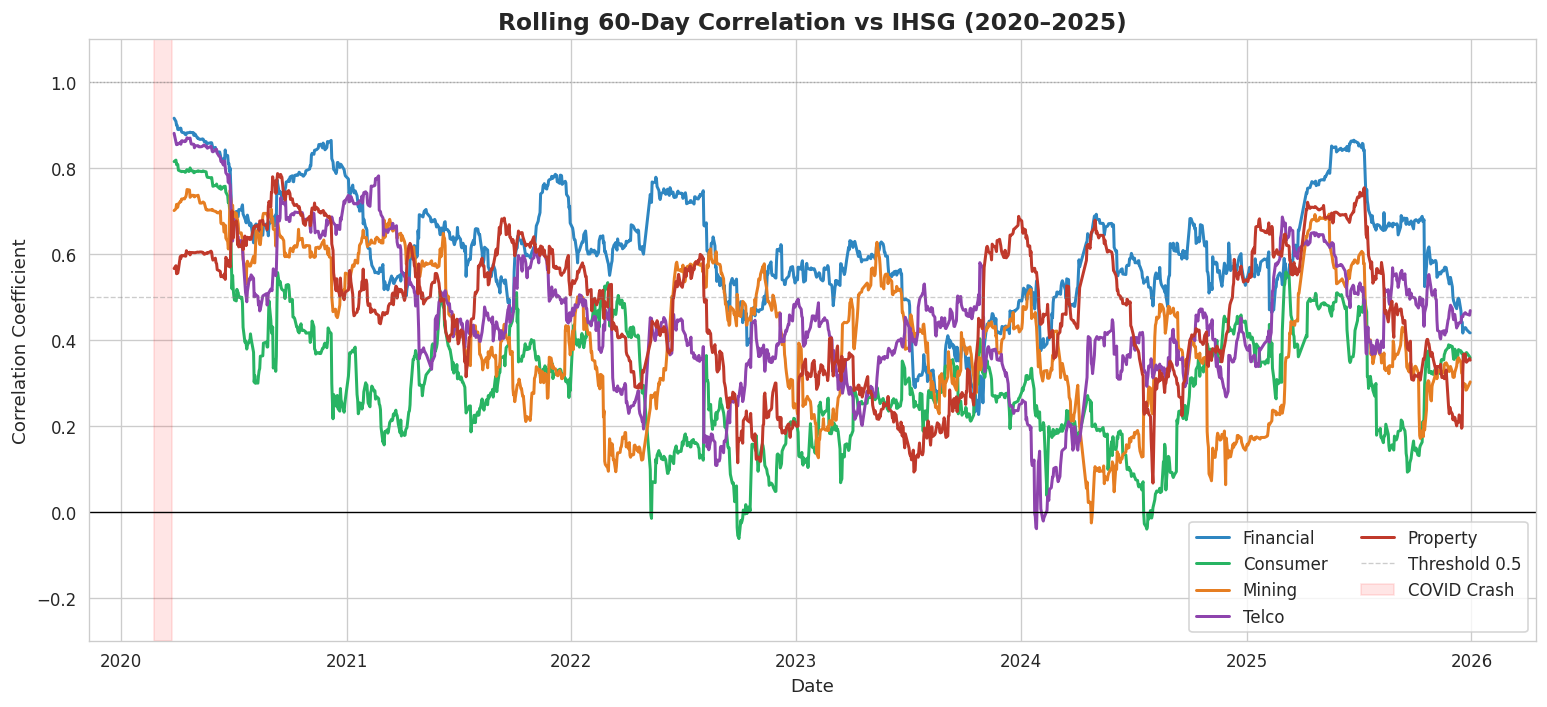

In [30]:
fig, ax = plt.subplots(figsize=(13, 6))

stocks = [col for col in daily_returns.columns if col != "IHSG"]

for stock in stocks:
    rolling_corr = daily_returns[stock].rolling(window=60).corr(daily_returns["IHSG"])
    ax.plot(rolling_corr.index, rolling_corr, label=stock, color=COLORS.get(stock, "#999999"),  linewidth=1.8)

ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.4, label="Threshold 0.5")
ax.axhline(0.0, color="black", linewidth=0.8)

ax.axvspan(pd.Timestamp("2020-02-24"), pd.Timestamp("2020-03-24"), alpha=0.10, color="red", label="COVID Crash")

ax.set_title("Rolling 60-Day Correlation vs IHSG (2020–2025)")
ax.set_ylabel("Correlation Coefficient")
ax.set_xlabel("Date")
ax.set_ylim(-0.3, 1.1)
ax.legend(loc="lower right", ncol=2)
plt.tight_layout()
plt.show()

In [31]:
print("=" * 55)
print("  INSIGHT DIVERSIFIKASI")
print("=" * 55)

print("\nKorelasi antar saham (ranking terendah → terbaik untuk diversifikasi):")
pairs = []
stocks_list = corr_matrix.columns.tolist()
for i in range(len(stocks_list)):
    for j in range(i+1, len(stocks_list)):
        s1 = stocks_list[i]
        s2 = stocks_list[j]
        corr_val = corr_matrix.loc[s1, s2]
        pairs.append((s1, s2, corr_val))

pairs_df = pd.DataFrame(pairs, columns=["Stock A", "Stock B", "Correlation"])
pairs_df = pairs_df.sort_values("Correlation")
pairs_df["Correlation"] = pairs_df["Correlation"].round(3)

print(pairs_df.to_string(index=False))

best_pair = pairs_df.iloc[0]
worst_pair = pairs_df.iloc[-1]

print(f"\nPasangan terbaik untuk diversifikasi:")
print(f"   {best_pair['Stock A']} & {best_pair['Stock B']} "
      f"(korelasi: {best_pair['Correlation']})")

print(f"\nPasangan paling mirip gerakannya:")
print(f"   {worst_pair['Stock A']} & {worst_pair['Stock B']} "f"(korelasi: {worst_pair['Correlation']})")

  INSIGHT DIVERSIFIKASI

Korelasi antar saham (ranking terendah → terbaik untuk diversifikasi):
  Stock A   Stock B  Correlation
 Consumer    Mining        0.148
 Consumer  Property        0.150
 Consumer     Telco        0.199
    Telco  Property        0.205
   Mining  Property        0.209
Financial  Consumer        0.231
   Mining     Telco        0.239
Financial    Mining        0.293
Financial  Property        0.357
     IHSG  Consumer        0.378
Financial     Telco        0.410
     IHSG    Mining        0.464
     IHSG  Property        0.515
     IHSG     Telco        0.547
     IHSG Financial        0.683

Pasangan terbaik untuk diversifikasi:
   Consumer & Mining (korelasi: 0.148)

Pasangan paling mirip gerakannya:
   IHSG & Financial (korelasi: 0.683)
